In [75]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [76]:
df = pd.read_csv('Clean_DS_jobs.csv')
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Min,Salary Max
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, Ny","New York, Ny",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"Emblemhealth, Unitedhealth Group, Aetna",NaN,NaN
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,Mantech\n4.2,"Chantilly, Va","Herndon, Va",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 To $2 Billion (Usd),-1,NaN,NaN
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, Ma","Boston, Ma",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 To $500 Million (Usd),-1,NaN,NaN
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,Inficon\n3.5,"Newton, Ma","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 To $500 Million (Usd),"Mks Instruments, Pfeiffer Vacuum, Agilent Tech...",NaN,NaN
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, Ny","New York, Ny",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",NaN,NaN


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              525 non-null    int64  
 1   Job Title          525 non-null    object 
 2   Salary Estimate    525 non-null    object 
 3   Job Description    525 non-null    object 
 4   Rating             525 non-null    float64
 5   Company Name       525 non-null    object 
 6   Location           525 non-null    object 
 7   Headquarters       525 non-null    object 
 8   Size               525 non-null    object 
 9   Founded            525 non-null    int64  
 10  Type of ownership  525 non-null    object 
 11  Industry           525 non-null    object 
 12  Sector             525 non-null    object 
 13  Revenue            525 non-null    object 
 14  Competitors        525 non-null    object 
 15  Salary Min         0 non-null      float64
 16  Salary Max         0 non-n

In [78]:
df = df.replace(-1, np.nan)
df = df.replace('-1', np.nan)
df = df.replace('Unknown / Non-Applicable', np.nan)

df.isnull().sum()

index                  0
Job Title              0
Salary Estimate        0
Job Description        0
Rating                 0
Company Name           0
Location               0
Headquarters           0
Size                   0
Founded                0
Type of ownership      0
Industry               3
Sector                 3
Revenue              170
Competitors          368
Salary Min           525
Salary Max           525
dtype: int64

In [79]:
def limpiar_salario(valor):
    if pd.isna(valor):
        return None
    
    valor = str(valor)
    valor_limpio = valor.replace('(Glassdoor est.)', '').replace('$', '').replace('K', '').strip()
    return valor_limpio

df['Salary Estimate Clean'] = df['Salary Estimate'].apply(limpiar_salario)

def extraer_min_salario(valor):
    if pd.isna(valor):
        return np.nan
    try:
        return int(valor.split('-')[0])
    except:
        return np.nan

def extraer_max_salario(valor):
    if pd.isna(valor):
        return np.nan
    try:
        return int(valor.split('-')[1])
    except:
        return np.nan

df['min_salary'] = df['Salary Estimate Clean'].apply(extraer_min_salario)
df['max_salary'] = df['Salary Estimate Clean'].apply(extraer_max_salario)

df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

df.drop('Salary Estimate Clean', axis=1, inplace=True)

df[['Salary Estimate', 'min_salary', 'max_salary', 'avg_salary']].head()

,Salary Estimate,min_salary,max_salary,avg_salary
0,$137K-$171K (Glassdoor est.),137,171.0,154.0
1,$137K-$171K (Glassdoor est.),137,171.0,154.0
2,$137K-$171K (Glassdoor est.),137,171.0,154.0
3,$137K-$171K (Glassdoor est.),137,171.0,154.0
4,$137K-$171K (Glassdoor est.),137,171.0,154.0


In [80]:
def limpiar_nombre_empresa(fila):
    nombre = str(fila['Company Name'])
    rating = fila['Rating']
    
    if pd.notna(rating):
        nombre = re.sub(r'\n\d.*', '', nombre)
    return nombre

df['company_txt'] = df.apply(limpiar_nombre_empresa, axis=1)

df[['Company Name', 'Rating', 'company_txt']].head()

,Company Name,Rating,company_txt
0,Healthfirst\n3.1,3.1,Healthfirst
1,Mantech\n4.2,4.2,Mantech
2,Analysis Group\n3.8,3.8,Analysis Group
3,Inficon\n3.5,3.5,Inficon
4,Affinity Solutions\n2.9,2.9,Affinity Solutions


In [81]:
def obtener_estado(ubicacion):
    if pd.isna(ubicacion):
        return np.nan
    
    partes = ubicacion.split(',')
    if len(partes) > 1:
        return partes[1].strip()
    else:
        return ubicacion

df['job_state'] = df['Location'].apply(obtener_estado)

df['job_state'] = df['job_state'].replace({'Anne Arundel': 'MD', 'New York': 'NY', 'United States': np.nan})

df['job_state'].value_counts().head()

job_state
Ca    122
Va     62
Ma     48
Ny     42
Md     37
Name: count, dtype: int64

In [82]:
columna_outlier = 'avg_salary'

df[columna_outlier].describe()

count    512.000000
mean     119.661133
std       36.764828
min       43.500000
25%       99.500000
50%      113.000000
75%      134.000000
max      271.500000
Name: avg_salary, dtype: float64

In [83]:
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < lower_bound) | (df[columna] > upper_bound)]
    return outliers

outliers_salario = detectar_outliers(df, columna_outlier)
len(outliers_salario)

30

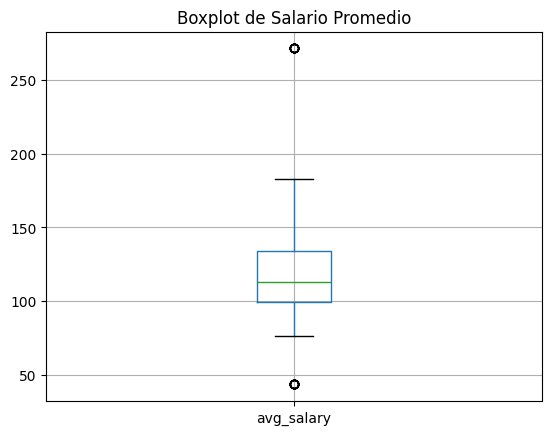

In [84]:
df.boxplot(column=[columna_outlier])
plt.title('Boxplot de Salario Promedio')
plt.show()

In [85]:
cols_to_drop = ['index', 'Salary Estimate']
df_cleaned = df.drop(columns=[c for c in cols_to_drop if c in df.columns], axis=1)

df_cleaned.head()

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Salary Min,Salary Max,min_salary,max_salary,avg_salary,company_txt,job_state
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, Ny","New York, Ny",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,NaN,"Emblemhealth, Unitedhealth Group, Aetna",NaN,NaN,137,171.0,154.0,Healthfirst,Ny
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,Mantech\n4.2,"Chantilly, Va","Herndon, Va",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 To $2 Billion (Usd),NaN,NaN,NaN,137,171.0,154.0,Mantech,Va
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, Ma","Boston, Ma",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 To $500 Million (Usd),NaN,NaN,NaN,137,171.0,154.0,Analysis Group,Ma
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,Inficon\n3.5,"Newton, Ma","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 To $500 Million (Usd),"Mks Instruments, Pfeiffer Vacuum, Agilent Tech...",NaN,NaN,137,171.0,154.0,Inficon,Ma
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, Ny","New York, Ny",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,NaN,"Commerce Signals, Cardlytics, Yodlee",NaN,NaN,137,171.0,154.0,Affinity Solutions,Ny
